In [1]:
from pathlib import Path
import os
import numpy as np
import arviz as az
import pickle
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
from os import listdir as ls
import h5py  # Make sure h5py initialises properly before pandas ruins it
import warnings

from emu_renewal.inputs import OUTPUTS_PATH
from emu_renewal.outputs import load_targets
from emu_renewal.plotting import plot_multianalysis_fit, plot_post_prior_comparison

set_matplotlib_formats("svg")

In [2]:
import pycountry
pycountry.countries.lookup("Bahrain")

Country(alpha_2='BH', alpha_3='BHR', flag='🇧🇭', name='Bahrain', numeric='048', official_name='Kingdom of Bahrain')

In [3]:
job_path = OUTPUTS_PATH / "44245473"
countries = ls(job_path)
n_cols = 3
c = "BHR"
analysis_dict = {d.name: Path(d.path) for d in os.scandir(job_path / c) if d.is_dir()}

spaghs = {a: pd.read_hdf(p / "spaghetti.h5") for a, p in analysis_dict.items()}
no_mob_path = analysis_dict["no_mob"]
targets = load_targets(no_mob_path)

In [6]:
msg = ".*axis already has a converter set*"
warnings.filterwarnings("ignore", message=msg)
pd.options.plotting.backend = "matplotlib"

In [17]:
from emu_renewal.inputs import ANALYSIS_TYPES

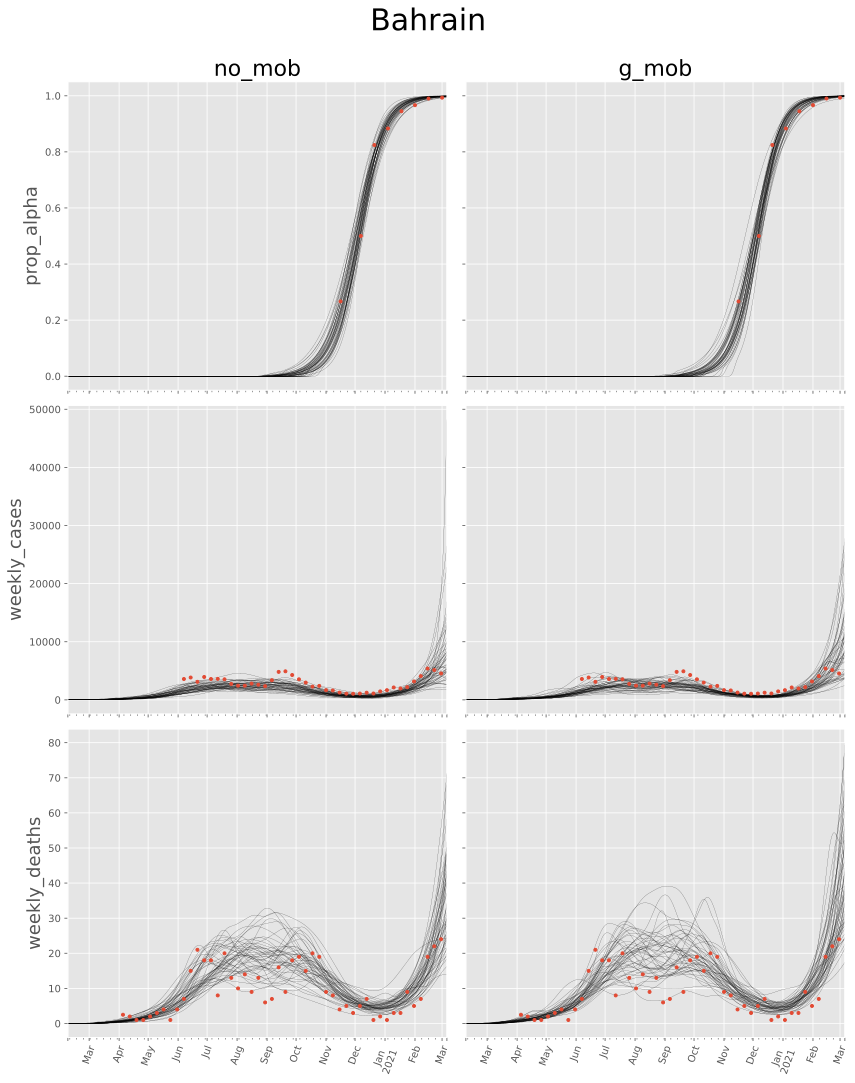

In [20]:
n_targs = len(targets)
fig, axes = plt.subplots(n_targs, len(spaghs), figsize=[12, 15], sharex=True, sharey="row")
country_name = pycountry.countries.lookup(c).name
fig.suptitle(country_name, fontsize=30, y=1.0)
ordered_analyses = [a for a in ANALYSIS_TYPES if a in spaghs]
for a, analysis in enumerate(ordered_analyses):
    a_spaghs = spaghs[analysis]
    for o, out in enumerate(targets):
        ax = axes[o, a]
        o_spagh = a_spaghs[out]
        o_spagh.plot(ax=ax, legend=False, color="black", linewidth=0.15)
        target = targets[out]
        ax.plot(target.index, target, linewidth=0.0, marker=".")
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=70)
        if o == 0:
            ax.set_title(analysis, fontsize=22)
        if a == 0:
            ax.set_ylabel(out, fontsize=18)
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)